Aluno: Afonso Henrique Guimarães de Oliveira


# CAPÍTULO 1: APRENDIZADO SUPERVISIONADO

Modelo de Machine Learning de crédito tendo em vista o histórico dos últimos clientes do banco. O objetivo é classificar um cliente em poor (provável mau pagador), standard (médio) ou good (provável bom pagador).

## Contexto

Você trabalha como cientista de dados em uma empresa financeira global. Ao longo dos anos, a empresa coletou informações bancárias básicas e reuniu uma grande quantidade de dados relacionados a crédito. A gerência deseja construir um sistema inteligente para segmentar as pessoas em faixas de pontuação de crédito, reduzindo assim o trabalho manual. (kaggle)

- ID:                                       Representa uma identificação única de um registro
- Customer_ID:                              Representa uma identificação única de uma pessoa
- Month:                                    Representa o mês do ano
- Name:                                     Representa o nome de uma pessoa
- Age:                                      Representa a idade da pessoa
- SSN:                                      Representa o número de seguridade social de uma pessoa
- Occupation:                               Representa a ocupação da pessoa
- Annual_Income:                            Representa a renda anual da pessoa
- Monthly_Inhand_Salary:                    Representa o salário base mensal de uma pessoa
- Num_Bank_Accounts:                        Representa o número de contas bancárias que uma pessoa possui
- Num_Credit_Card:                          Representa o número de outros cartões de crédito que uma pessoa possui
- Interest_Rate:                            Representa a taxa de juros no cartão de crédito
- Num_of_Loan:                              Representa o número de empréstimos tomados no banco
- Type_of_Loan:                             Representa os tipos de empréstimo tomados por uma pessoa
- Delay_from_due_date:                      Representa o número médio de dias de atraso em relação à data de vencimento
- Num_of_Delayed_Payment:                   Representa o número médio de pagamentos atrasados por uma pessoa
- Changed_Credit_Limit:                     Representa a variação percentual no limite do cartão de crédito
- Num_Credit_Inquiries:                     Representa o número de consultas ao cartão de crédito
- Credit_Mix:                               Representa a classificação da combinação de créditos
- Outstanding_Debt:                         Representa a dívida restante a ser paga (em USD)
- Credit_Utilization_Ratio:                 Representa a taxa de utilização do cartão de crédito
- Credit_History_Age:                       Representa a idade do histórico de crédito da pessoa
- Payment_of_Min_Amount:                    Representa se apenas o valor mínimo foi pago pela pessoa
- Total_EMI_per_month:                      Representa os pagamentos mensais de parcelas (em USD)
- Amount_invested_monthly:                  Representa o valor mensal investido pelo cliente (em USD)
- Payment_Behaviour:                        Representa o comportamento de pagamento do cliente (em USD)
- Monthly_Balance:                          Representa o saldo mensal do cliente (em USD)


Fonte: Kaggle

### Features Disponíveis

### Target

- Credit_Score:                             Representa a classificação do cliente como mal, médio ou bom pagador (Alvo)

## Carregamento dos dados

In [1]:
!pip install pandas

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
data = pd.read_csv(r"./data/train.csv")
# data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/train.csv")


/tmp/ipykernel_1866054/186379594.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"./data/train.csv")


Apenas a base de treino foi carregada, pois a de teste não possui a coluna Credit_Score, o que indica que se trata de uma base para avaliar um modelo já completo (treinado e testado), pelo Kaggle ou pelos autores do desafio.

## Análise Exploratória dos Dados

In [5]:
data

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7,11.5,3.0,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7,11.5,3.0,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6,11.5,3.0,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,NaN,11.5,3.0,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Há dados nulos nas colunas:
- Name,
- Monthly_Inhand_Salary,
- Type_of_Loan,
- Num_of_Delayed_Payment,
- Num_Credit_Inquiries,
- Credit_History_Age,
- Amount_invested_monthly,              
- Monthly_Balance

No entando a coluna name não tem valor para o modelo, assim como ID, SSN e Customer_ID.

Há também colunas que deveriam ser numéricas, mas estão como object:
- Age,
- Annual_Income,
- Num_of_Loan,
- Num_of_Delayed_Paymen,
- Changed_Credit_Limit,                  
- Outstanding_Debt,
- Credit_History_Age,
- Amount_invested_monthly,
- Monthly_Balance        

Isso evidencia a necessidade de limpeza dos dados. No entanto, nenhum tratamento precisa ser feita em Age, pois essa coluna deve ser desprezada a fim de evitar que o modelo inclua qualquer tipo de preconceito baseado na faixa etária do cliente.

Observando os dados contidos no dataframe, para um mesmo cliente em uma mesma feature há dados consistentes em uma linha e inconsistentes em outra. Por exemplo, em Annual_Income há dados para um mesmo cliente com um underline ao final do número, enquanto de as demais linhas possuem valores limpos. Faz sentido então usar uma estratégia de substitituição de valores considerando os valores associados ao mesmo cliente.

In [7]:
data.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [8]:
data.groupby("Customer_ID").agg("count")

,ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
Customer_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
CUS_0x1000,8,8,7,8,8,8,8,7,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
CUS_0x1009,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,7,8,8,8,8,8,8
CUS_0x100b,8,8,7,8,8,8,8,7,8,8,8,8,0,8,8,8,8,8,8,8,7,8,8,7,8,8,8
CUS_0x1011,8,8,8,8,8,8,8,7,8,8,8,8,8,8,6,8,8,8,8,8,8,8,8,8,8,8,8
CUS_0x1013,8,8,8,8,8,8,8,5,8,8,8,8,8,8,7,8,8,8,8,8,7,8,8,8,8,8,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CUS_0xff3,8,8,6,8,8,8,8,7,8,8,8,8,8,8,8,8,8,8,8,8,7,8,8,8,8,8,8
CUS_0xff4,8,8,7,8,8,8,8,7,8,8,8,8,8,8,8,8,6,8,8,8,7,8,8,8,8,8,8
CUS_0xff6,8,8,8,8,8,8,8,8,8,8,8,8,8,8,7,8,7,8,8,8,8,8,8,7,8,7,8


Cabe mais uma ressalva quanto ao ID do cliente, pois há 8 registros por cliente. Apesar da inutilidade da coluna para o modelo, esta pode ser útil para agrupar dados e produção de novas features.

In [9]:
!pip install matplotlib

Credit_Score
Standard    0.53174
Poor        0.28998
Good        0.17828
Name: proportion, dtype: float64


<Axes: >

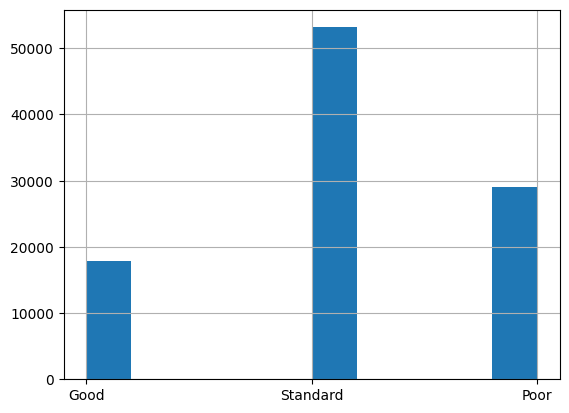

In [10]:
print(data['Credit_Score'].value_counts(normalize=True))
data['Credit_Score'].hist()

O histograma e o value_counts do target revelam que há um desbalanceamento dos dados, de modo que mais da metade dos clientes possuem a classificação de pagador médio, enquanto que menos de 20% são prováveis bons pagadores. Isso revela a importancia de usar estratificação na divisão de treino e teste. Pode-se também realizar o balanceamento dos dados com algumas das ferramentas disponibilizadas pelo python, especialmente o sklearn.

## Agrupamento dos Dados

Minha primeira tentativa foi treinar modelos com 80.000 linhas de treino e 20.000 de testes. No entanto, o SVM e o Adabosting estavam levando muito tempo para concluir. Não deixei esssa tentativa no arquivo pois as células levariam bastante tempo pra concluir. Aliado a isso, há 8 linhas por cliente e o objetivo do modelo é classificar os clientes como potenciais bom, médio ou mal pagadores. Então decidi agrupar os dados por cliente. Percebi que seria necessário fazer isso antes da divisão em treino e teste, pois quero evitar que existam dados de um mesmo cliente no treino e no teste, o que poderia implicar num vazamento de dados. Isso também gerou a necessidade de adiantar o pré-processamento para antes do split.

Via de regra, colunas numéricas serão agrupadas pela média e colunas categóricas serão agrupadas pela moda. Para isso crio as duas funções abaixo para realizar o agrupamento. No entanto não as aplico ainda pois há colunas que deveriam ser numéricas e não o são.

In [11]:
!pip install numpy

In [12]:
import numpy as np
def Agrupar_Dados(df: pd.DataFrame):

    #compressão de dicionário para gerar uma estrutura chave valor cuja chave é o nome da coluna e o valor é "mean", indicando para o agg que quero agrupar a coluna pela média
    agg_dict_num = {
        col: "mean" 
            for col in df.select_dtypes(include=np.number).columns.tolist()
                  if col != 'Customer_ID'
    }

    df_group_num = df.groupby("Customer_ID").agg(agg_dict_num).reset_index()


    agg_dict_cat = {
        col: lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan 
            for col in df.select_dtypes(exclude=np.number).columns.tolist()
                if col != 'Customer_ID'
    }

    df_group_cat = df.groupby("Customer_ID").agg(agg_dict_cat).reset_index()

    df_group = pd.merge(left=df_group_num, right=df_group_cat, how='inner', on='Customer_ID')

    return df_group

## Pré-processamento de Dados

Algumas colunas do dataset original não possuem valor real para o modelo, como ID, Nome e identificador do Seguro Social. Então crio uma uma função que poderá ser reutilizada para  qualquer dos dataframes deste problema, mesmo já divididos em treino e test. A coluna Age é excluída para evitar a introdução de qualquer pre-conceito no modelo.

### Funções de Pré-Processamento


In [13]:
def Drop_Columns (df: pd.DataFrame, columns_drop:list = ['ID', 'Name', 'Age', 'SSN']):
    return df.drop(columns=columns_drop, errors="ignore")


Criei uma função para transformar a coluna Credit_History_Age em float já que seus dados indicam um período em anos na forma de string. Ex.: "17 Years and 1 Months	"

In [14]:
import re
import numpy as np
def Convert_String_To_Time(value):
    match = False
    if not isinstance(value, str):
        return np.nan

    match = re.search(r'(\d+) Years? and (\d+) Months?', value)

    if not match:
        return np.nan

    y, m = match.groups()

    return int(y) + int(m)/12

Algumas colunas que deveriam ser float não o são por causa de um underline após o valor correto. A função abaixo serve para remover.


In [15]:
def Convert_String_To_Float(value):
    if isinstance(value, float): return value

    try:
        return round(float(value.replace('_', '')),2)
    except Exception:
        return np.nan



A Função a seguir é semelhante à primeira, mas aplica-se a coluna Changed_Credit_Limit, em que há alguns dados apenas com um traço, o que pode indicar que não houve mudança no limite de crédito. Então por padrão substitui por zero ou chama a função anterior.

In [16]:
def Convert_String_To_Float_Default_Zero(value):
    if isinstance(value, float): return value

    try:
        if value == '-': return 0
        return Convert_String_To_Float(value)
    except Exception:
        return np.nan

A próxima função aplica as funções anteriores às colunas que deveriam ser numéricas.

In [17]:
def Clear_Data_Should_number(df: pd.DataFrame):

  columns_number = [
      'Annual_Income',
      'Num_of_Loan',
      'Num_of_Delayed_Payment',
      'Outstanding_Debt',
      'Amount_invested_monthly',
      'Monthly_Balance',
    ]
  columns_delta = ['Changed_Credit_Limit']
  columns_time_stamp = ['Credit_History_Age']


  df[columns_number + columns_delta + columns_time_stamp]


  for col in columns_number:
    df[col] = df[col].apply(Convert_String_To_Float)
    df[col] = df[col].astype(float)

  for col in columns_delta:
    df[col] = df[col].apply(Convert_String_To_Float_Default_Zero)
    df[col] = df[col].astype(float)

  for col in columns_time_stamp:
    df[col] = df[col].apply(Convert_String_To_Time)
    df[col] = df[col].astype(float)

  print(df.info())

  return df



In [18]:
!pip install scikit-learn

Ao tentar fazer o transform do OneHotEncoder nas features de test, obtive uma mensagem de que colunas desconhecidas foram encontradas. Certamente porque combinações novas de tipos de empréstimos (Type_of_Loan) foram lá encontradas. Essa coluna possui em cada linha uma lista dos tipos de empréstimos que cada cliente tem. 

Tentando resolver isso, descobri o MultiLabelBinarizer, que a parti de uma única coluna com uma tupla de valores em seu conteúdo gera uma nova  coluna pra cada possível valor, semelhante ao OneHotEncoder, mas trabalhando com uma tupla como valor de uma coluna. 

Primeiro separo os valores existentes em cada célula da coluna, gerando a tupla necessária. Depois aplico o MultilabelBinarizer para gerar uma coluna para cada possível valor das tuplas. Em seguida junto os dados gerados com o df original. 

Pesquisei sobre se usá-lo antes do split provocaria algum data leakage, mas como se trata de uma variável catetóriga e o MultiLabelBinarizer não tem acesso ao Target (recebe apenas a coluna Type_of_Loan), seu uso é seguro.

In [19]:
from sklearn.preprocessing import MultiLabelBinarizer
def Expand_Type_of_Loan(df: pd.DataFrame):

    df['Type_of_Loan'] = df['Type_of_Loan'].fillna(df['Type_of_Loan'].mode()[0])

    df['Type_of_Loan'] = df['Type_of_Loan'].str.replace("and ", "").str.split(', ')

    mlb = MultiLabelBinarizer()

    loans = pd.DataFrame(
        mlb.fit_transform(df['Type_of_Loan']),
        columns=mlb.classes_,
        index=df.index
    )

    df = pd.concat([df.drop('Type_of_Loan', axis=1), loans], axis=1)

    return df

### Pré-processando
Agora, aplico as funções de limpeza.

In [20]:
data = Drop_Columns(data)

data  = Clear_Data_Should_number(data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   Month                     100000 non-null  object 
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  float64
 9   Type_of_Loan              88592 non-null   object 
 10  Delay_from_due_date       100000 non-null  int64  
 11  Num_of_Delayed_Payment    92998 non-null   float64
 12  Changed_Credit_Limit      97909 non-null   float64
 13  Num_Credit_Inquiries      98035 non-null   fl

### Agrupando
Por fim, aplico a função que gera novas colunas para Type_of_Loan e a função de agrupamento.

In [21]:
data = Expand_Type_of_Loan(df=data)
data = Agrupar_Dados(df=data)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  object 
 1   Annual_Income             12500 non-null  float64
 2   Monthly_Inhand_Salary     12500 non-null  float64
 3   Num_Bank_Accounts         12500 non-null  float64
 4   Num_Credit_Card           12500 non-null  float64
 5   Interest_Rate             12500 non-null  float64
 6   Num_of_Loan               12500 non-null  float64
 7   Delay_from_due_date       12500 non-null  float64
 8   Num_of_Delayed_Payment    12500 non-null  float64
 9   Changed_Credit_Limit      12500 non-null  float64
 10  Num_Credit_Inquiries      12500 non-null  float64
 11  Outstanding_Debt          12500 non-null  float64
 12  Credit_Utilization_Ratio  12500 non-null  float64
 13  Credit_History_Age        12500 non-null  float64
 14  Total_

## Divisão dos Dados em Treino e Test

Feito o pré-processamento dos dados, somente naquilo que era necessário ao agrupamento dos dados, realizaremos a separação do target das demais colunas e a divisão do dataframe em treino e teste.

Separação do Target

In [22]:

X = data.drop(columns="Credit_Score")
Y = data["Credit_Score"]

Particionamento dos dados em treino e teste.

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


### Preenchimento de Dados Ausentes nas Features de Treino


#### Features Numéricas


Por meio do SimpleImputer substituo os valores nulos pela média global de cada feature no conjunto das features numéricas. 

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.impute import SimpleImputer
import numpy as np

features_num = X_train.select_dtypes(include=np.number).columns.tolist()
num_imputer = SimpleImputer(strategy="mean")
X_train[features_num] = num_imputer.fit_transform(X_train[features_num])

Em seguida, aplico o standardScaler a fim de que o modelo não dê mais importância a uma feature em razão dos seus valores mais elevados ou que despreze outra em função de seus baixos valores. O Scaler padroniza os dados.

In [25]:
scaler = StandardScaler()
X_train[features_num] = scaler.fit_transform(X_train[features_num])
X_train[features_num].info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1695 to 6792
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Annual_Income             10000 non-null  float64
 1   Monthly_Inhand_Salary     10000 non-null  float64
 2   Num_Bank_Accounts         10000 non-null  float64
 3   Num_Credit_Card           10000 non-null  float64
 4   Interest_Rate             10000 non-null  float64
 5   Num_of_Loan               10000 non-null  float64
 6   Delay_from_due_date       10000 non-null  float64
 7   Num_of_Delayed_Payment    10000 non-null  float64
 8   Changed_Credit_Limit      10000 non-null  float64
 9   Num_Credit_Inquiries      10000 non-null  float64
 10  Outstanding_Debt          10000 non-null  float64
 11  Credit_Utilization_Ratio  10000 non-null  float64
 12  Credit_History_Age        10000 non-null  float64
 13  Total_EMI_per_month       10000 non-null  float64
 14  Amount_in

#### Features Categóricas
A seguir seleciono as features categóricas e com o SimpleImputer preencho os valores nulos com o valor mais frequente (moda). Isso é feito em cada coluna. A coluna Personal Loan Posui múltiplos valores para cada cliente, representando todos os tipos de empréstimo que o cliente tem.

In [26]:
features_cat = X_train.select_dtypes(exclude=np.number).columns.tolist()
features_cat.remove("Customer_ID")
print(features_cat)

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[features_cat] = cat_imputer.fit_transform(X_train[features_cat])

['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


Agora faço a transformação dos dados categóricos em numéricos através do OneHotEncoder, semelhante ao que faz o dummies do pandas. Como resultado, há uma coluna para cada possível valor da featur original. Se o valor orginal era A a coluna que representa essa informação terá o valor 1 e as demais 0. 



In [27]:
encoder = OneHotEncoder()
X_train_cat_encoded = encoder.fit_transform(X_train[features_cat])

#### Dados de Treino Preenchidos
Por fim uso o numpy hstack para juntar dados categóricos e numéricos

In [28]:
X_train_preprocessed = np.hstack((X_train[features_num], X_train_cat_encoded.toarray()))

### Preenchimento de Dados Ausentes nas Features de Teste

In [29]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 6874 to 1249
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               2500 non-null   object 
 1   Annual_Income             2500 non-null   float64
 2   Monthly_Inhand_Salary     2500 non-null   float64
 3   Num_Bank_Accounts         2500 non-null   float64
 4   Num_Credit_Card           2500 non-null   float64
 5   Interest_Rate             2500 non-null   float64
 6   Num_of_Loan               2500 non-null   float64
 7   Delay_from_due_date       2500 non-null   float64
 8   Num_of_Delayed_Payment    2500 non-null   float64
 9   Changed_Credit_Limit      2500 non-null   float64
 10  Num_Credit_Inquiries      2500 non-null   float64
 11  Outstanding_Debt          2500 non-null   float64
 12  Credit_Utilization_Ratio  2500 non-null   float64
 13  Credit_History_Age        2500 non-null   float64
 14  Total_EMI_

#### Features Numéricas
Para evitar vazamento de dados, o simpleInputer e o StandardScaler são aplicados aos dados de teste apenas com a função transform, pois já foram treinados no dados de treino. Isso evita vazamento de dados.

In [30]:
X_test[features_num] = num_imputer.transform(X_test[features_num])
X_test[features_num] = scaler.transform(X_test[features_num])

#### Features Categóricas
O mesmo se aplica às features categóricas.

In [31]:
X_test[features_cat] = cat_imputer.transform(X_test[features_cat])
X_test_cat_encoded = encoder.transform(X_test[features_cat])


Por fim, juntamos os dados numérios e categóricos, do mesmo modo em que feitos nos dados de treino.

In [32]:
X_test_preprocessed = np.hstack((X_test[features_num], X_test_cat_encoded.toarray()))

## Funções Para Gerar Métricas
Criei funções para gerar as métricas dos modelos de classificação, a fim de reutilizá-las em cada modelo treinado.

In [33]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

def Gerar_Dados(X, Y, estimator):
    y_pred = estimator.predict(X)
    cm = confusion_matrix(Y, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=estimator.classes_).plot(cmap='viridis')
    plt.legend()
    plt.show()
    print(classification_report(Y, y_pred))

    lb = LabelBinarizer()
    Y_bin = lb.fit_transform(Y)
    Y_score = estimator.decision_function(X)

    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(estimator.classes_):
        fpr, tpr, _ = roc_curve(Y_bin[:, i], Y_score[:, i])
        plt.plot(fpr, tpr, label=f'{class_name} (AUC = {auc(fpr, tpr):.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()


def Metrics_Classification(estimator, X_train, X_test, Y_train, Y_test):
  print("Métricas de Avaliação de Treino: ")
  Gerar_Dados(X_train, Y_train, estimator)

  print("Métricas de Avaliação de Teste: ")
  Gerar_Dados(X_test, Y_test, estimator)



## SVM

In [34]:
from sklearn.svm import SVC

svm_model = SVC(C=1.0, random_state=42, kernel="linear")
svm_model.fit(X_train_preprocessed, Y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Métricas de Avaliação de Treino: 


/tmp/ipykernel_1866054/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


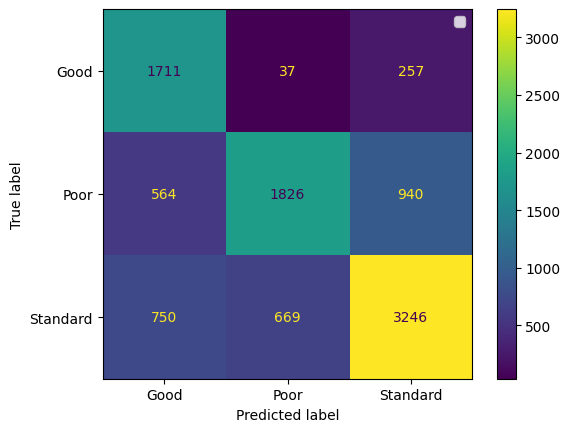

              precision    recall  f1-score   support

        Good       0.57      0.85      0.68      2005
        Poor       0.72      0.55      0.62      3330
    Standard       0.73      0.70      0.71      4665

    accuracy                           0.68     10000
   macro avg       0.67      0.70      0.67     10000
weighted avg       0.69      0.68      0.68     10000



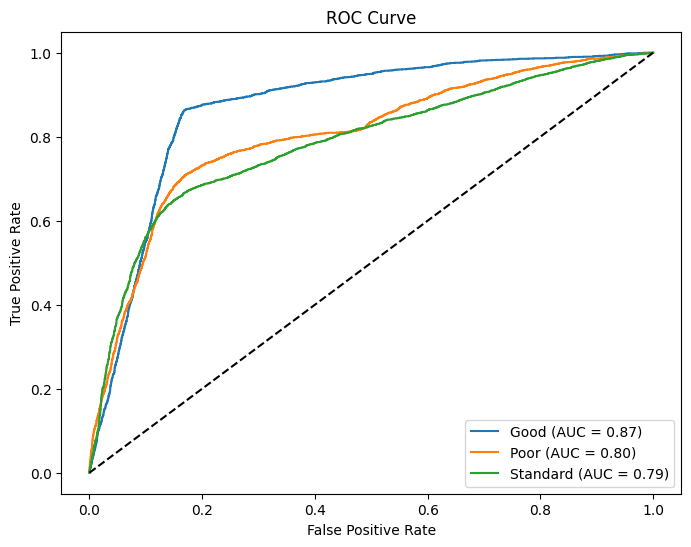

Métricas de Avaliação de Teste: 


/tmp/ipykernel_1866054/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


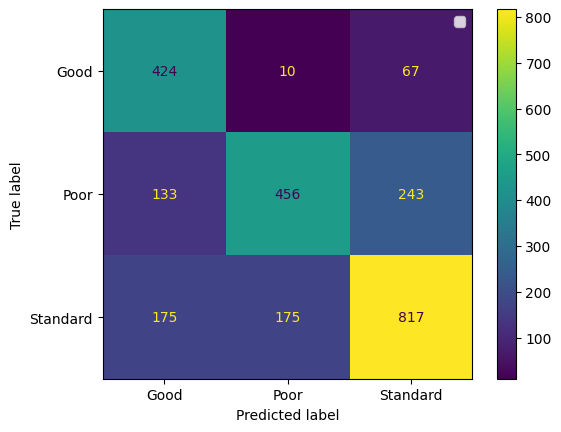

              precision    recall  f1-score   support

        Good       0.58      0.85      0.69       501
        Poor       0.71      0.55      0.62       832
    Standard       0.72      0.70      0.71      1167

    accuracy                           0.68      2500
   macro avg       0.67      0.70      0.67      2500
weighted avg       0.69      0.68      0.68      2500



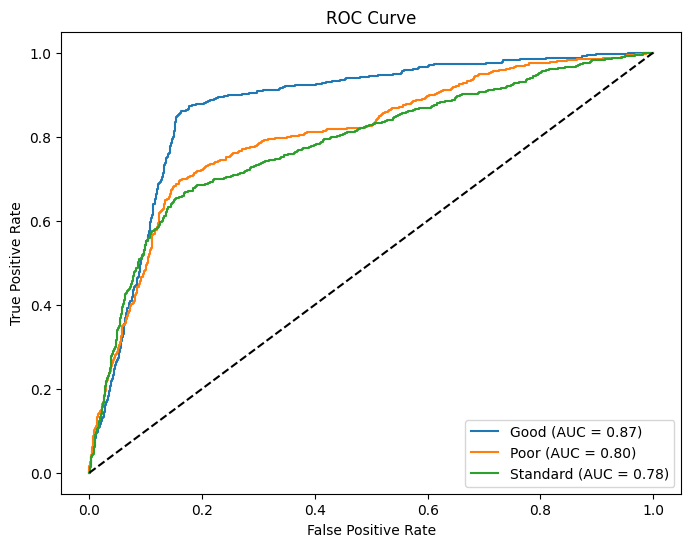

In [35]:
Metrics_Classification(svm_model, X_train_preprocessed, X_test_preprocessed, Y_train, Y_test)

Ao comparar os resultados de treino e teste, apesar do resultado ser apenas razoável (acurácia de 0,68 nos treinos e testes), observa-se que não houve overfitting. Considerando que se trata de um classificador de score de crédito, o pior erro cometido pelo modelo é o falso positivo, que representam aqueles classificados como bons ou regulares pagadores mas não o são, gerando empréstimos para aqueles que são maus pagadores, ou oferecer crédito acima da capacidade de pagamento. Dito isso, a métrica precision ganha relevância sobre o recall.

Sobre esse aspecto, o modelo se mostra melhor em classificar clientes como maus ou regulares pagadores.

No entanto, a classe Good apresenta a melhor AUC em função da sua alta capacidade de identificar os verdadeiros positivos. A capacidade de identificar verdadeiros positivos nas demais classes é inferior, mas semelhantes entre si. O modelo é mais preciso ao classificar clientes como Poor ou Standard, cometendo menos erros, embora possa deixar de identificar corretamente alguns desses casos (baixo recall).

### Modelos de Boosting

In [36]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train_preprocessed, Y_train)


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


Métricas de Avaliação de Treino: 


/tmp/ipykernel_1866054/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


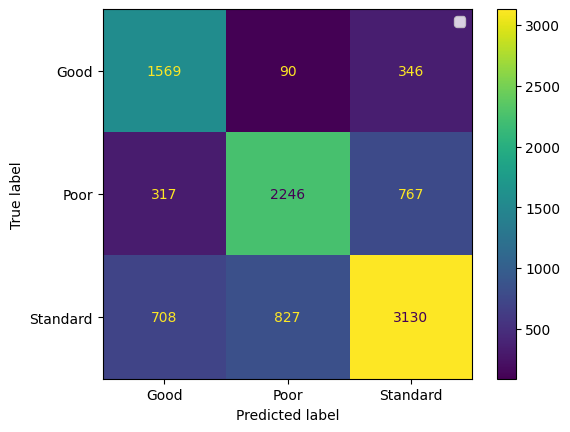

              precision    recall  f1-score   support

        Good       0.60      0.78      0.68      2005
        Poor       0.71      0.67      0.69      3330
    Standard       0.74      0.67      0.70      4665

    accuracy                           0.69     10000
   macro avg       0.68      0.71      0.69     10000
weighted avg       0.70      0.69      0.70     10000



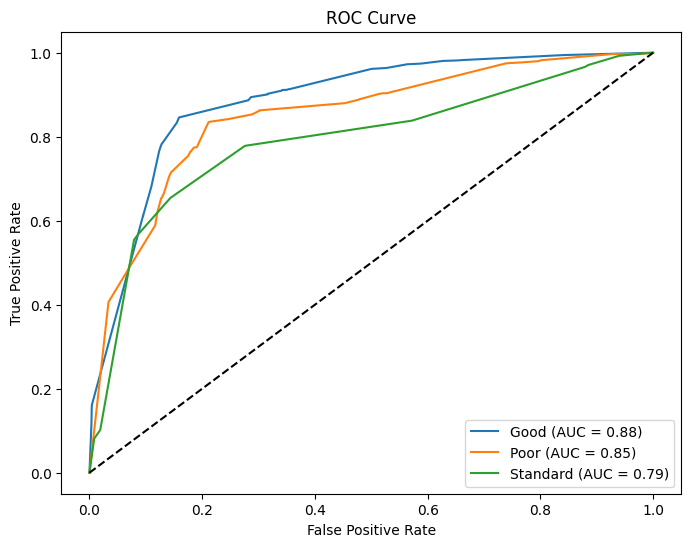

Métricas de Avaliação de Teste: 


/tmp/ipykernel_1866054/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


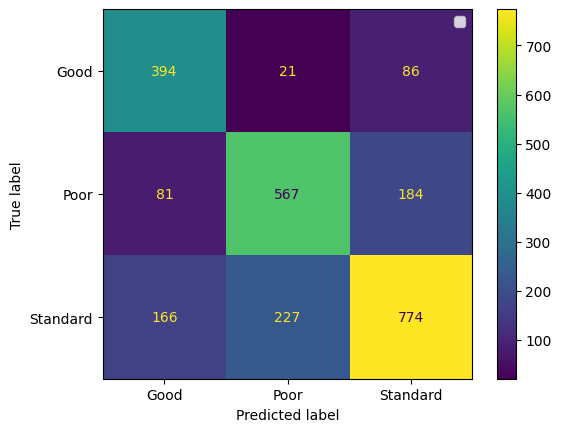

              precision    recall  f1-score   support

        Good       0.61      0.79      0.69       501
        Poor       0.70      0.68      0.69       832
    Standard       0.74      0.66      0.70      1167

    accuracy                           0.69      2500
   macro avg       0.68      0.71      0.69      2500
weighted avg       0.70      0.69      0.69      2500



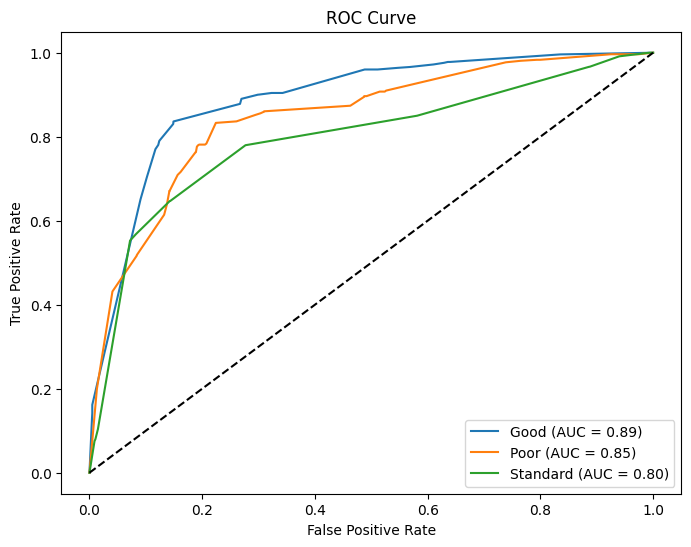

In [37]:
Metrics_Classification(adaboost_model, X_train_preprocessed, X_test_preprocessed, Y_train, Y_test)

O AdaBoosting apresentou desempenhos semelhantes em treino e teste, indicando ausência de overfitting. O modelo identifica melhor clientes da classe Good (maior recall), enquanto o melhor percentual de acerto nas classificações ocorre na classe Standard (melhor precision).

A classe Good apresenta melhor AUC em função de sua maior capacidade de identificar os clientes que realmente são bons pagadores. A classe Poor apresenta a segunda melhor AUC em decorrência do equilíbrio entre precisão e recall.

Esses dados mostram que esse modelo teria um razoável percentual de acerto ao recusar crédito, mas apresenta performance inferior ao classificar um cliente como bom pagador, considerando a precisão mais baixa, o que pode causar distorção no montante concedido. 

Ao comparar os dois modelos (SVM e AdaBoosting) observa-se no geral desempenhos semelhantes. A principal diferença está no recall da classe poor, sendo 0,68 no AdaBoosting e 0,55 no SVM.  Isso mostra um "viés" mais conservador do AdaBoosting em comparação ao SVM, pois este tem menor capacidade de identificar maus pagadores, recultando na concessão equivodada de crédito com maior frequência. Apesar disso, o recall de ambos é apenas razoável, o que significa que o AdaBoosting só pode ser considerado "conservador" em comparação ao modelo treinado com SVM.

## Escolha de hiperparâmetros

A fim de melhorar o desempenho dos modelos, podemos testar vários hiperparâmentros. Para tornar o processo mais prático, criarei uma lista de dicionários, sendo um para cada modelo, com os respectivos hiperparâmetros a serem testados.

In [38]:
models = [
    {

        'name': "AdaBoostClassifier",
        'model': AdaBoostClassifier(random_state=42),
        'paramns': {
            'n_estimators': [50, 75, 100, 150],                 # Número de estimadores fracos (por padrão, árvores rasas)
            'learning_rate': [0.5, 1.0, 1.5],                   # Taxa de aprendizado — controla o peso de cada estimador
        }
    },
    {
        'name': "SVC",
        'model': SVC(random_state=42),
        'paramns':
            {
                "kernel": ["linear", "rbf", "poly"],            #função de transformação de dimensionalidade
                "C": np.logspace(-2, 2, 5),                     #representa o quão suave o modelo será. Quanto menor, mais suável.
                "gamma": np.logspace(-2, 2, 5)                  #influência de cada ponto na fronteira de decisão. Alto gama = somente pontos próximos são considerados.
            }

    }
]

## Treinamento dos modelos


Para otimizar ainda mais o processo, podemos usar o GridSearchCV, que testará todas as combinações de parâmetros do modelo. Usarei um loop para iterar sobre o dicionário, e aplicar o GridSearchCV em cada modelo e guardar os resultados da melhor cominação no respectivo dicionário. 

Além disso, usarei o StratifiedKFold, a fim de reduzir a possibilidade de que qualquer modelo, em qualquer combinação de hiperparâmetros apresente overfitting. O StratifiedKFold, mantem a proporção do target dos dados originiais, o que é importante visto que as classes estão desbalanceadas.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #diviviu em 5 folds, com embarlhamento para garantir que um fold não terá prevalência de uma classe
for model in models:
    grid = GridSearchCV(
        estimator=model['model'],
        param_grid=model['paramns'],
        cv=cv,
        verbose=10,
        n_jobs=-1,
        scoring=scoring,  # métricas de classificação
        refit='precision',
        return_train_score=True
    )

    grid.fit(X_train_preprocessed, Y_train)

    print(model['name'])

    print('Melhor Estimador:', grid.best_estimator_)
    print('Melhores Parâmetros:', grid.best_params_)
    print('Melhor Score (validação):', grid.best_score_)

    model['estimador'] = grid.best_estimator_
    model['best_paramns'] = grid.best_params_
    model['score'] = grid.best_score_
    model['results'] = grid.cv_results_

Fitting 5 folds for each of 12 candidates, totalling 60 fits


[CV 4/5; 1/12] START learning_rate=0.5, n_estimators=50.........................
[CV 3/5; 1/12] START learning_rate=0.5, n_estimators=50.........................
[CV 5/5; 1/12] START learning_rate=0.5, n_estimators=50.........................
[CV 2/5; 1/12] START learning_rate=0.5, n_estimators=50.........................
[CV 1/5; 1/12] START learning_rate=0.5, n_estimators=50.........................
[CV 1/5; 2/12] START learning_rate=0.5, n_estimators=75.........................
[CV 5/5; 1/12] END learning_rate=0.5, n_estimators=50; accuracy: (train=0.703, test=0.702) f1: (train=0.705, test=0.704) precision: (train=0.724, test=0.724) recall: (train=0.703, test=0.702) total time=   2.8s
[CV 2/5; 2/12] START learning_rate=0.5, n_estimators=75.........................
[CV 2/5; 1/12] END learning_rate=0.5, n_estimators=50; accuracy: (train=0.706, test=0.694) f1: (train=0.708, test=0.696) precision: (train=0.726, test=0.716) recall: (train=0.706, test=0.694) total time=   2.7s[CV 4/5; 1/1

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 2/75] END C=0.01, gamma=0.01, kernel=rbf; accuracy: (train=0.535, test=0.533) f1: (train=0.459, test=0.457) precision: (train=0.461, test=0.462) recall: (train=0.535, test=0.533) total time=  14.6s
[CV 2/5; 3/75] START C=0.01, gamma=0.01, kernel=poly............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 3/75] END C=0.01, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.218) recall: (train=0.467, test=0.467) total time=  13.1s
[CV 3/5; 3/75] START C=0.01, gamma=0.01, kernel=poly............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 2/75] END C=0.01, gamma=0.01, kernel=rbf; accuracy: (train=0.539, test=0.536) f1: (train=0.463, test=0.461) precision: (train=0.465, test=0.462) recall: (train=0.539, test=0.536) total time=  12.7s
[CV 4/5; 3/75] START C=0.01, gamma=0.01, kernel=poly............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 2/75] END C=0.01, gamma=0.01, kernel=rbf; accuracy: (train=0.541, test=0.537) f1: (train=0.467, test=0.462) precision: (train=0.465, test=0.460) recall: (train=0.541, test=0.537) total time=  14.5s
[CV 5/5; 3/75] START C=0.01, gamma=0.01, kernel=poly............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 2/75] END C=0.01, gamma=0.01, kernel=rbf; accuracy: (train=0.535, test=0.544) f1: (train=0.459, test=0.470) precision: (train=0.460, test=0.468) recall: (train=0.535, test=0.544) total time=  15.3s
[CV 1/5; 4/75] START C=0.01, gamma=0.1, kernel=linear...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 2/75] END C=0.01, gamma=0.01, kernel=rbf; accuracy: (train=0.539, test=0.533) f1: (train=0.464, test=0.456) precision: (train=0.465, test=0.459) recall: (train=0.539, test=0.533) total time=  15.5s
[CV 2/5; 4/75] START C=0.01, gamma=0.1, kernel=linear...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 3/75] END C=0.01, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.466) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.217) recall: (train=0.467, test=0.466) total time=  13.0s
[CV 3/5; 4/75] START C=0.01, gamma=0.1, kernel=linear...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 4/75] END C=0.01, gamma=0.1, kernel=linear; accuracy: (train=0.675, test=0.680) f1: (train=0.673, test=0.680) precision: (train=0.691, test=0.699) recall: (train=0.675, test=0.680) total time=   7.7s
[CV 4/5; 4/75] START C=0.01, gamma=0.1, kernel=linear...........................
[CV 1/5; 4/75] END C=0.01, gamma=0.1, kernel=linear; accuracy: (train=0.674, test=0.670) f1: (train=0.671, test=0.668) precision: (train=0.691, test=0.684) recall: (train=0.674, test=0.670) total time=   8.1s
[CV 5/5; 4/75] START C=0.01, gamma=0.1, kernel=linear...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 3/75] END C=0.01, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.218) recall: (train=0.467, test=0.467) total time=  13.6s
[CV 1/5; 5/75] START C=0.01, gamma=0.1, kernel=rbf..............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 3/75] END C=0.01, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.218) recall: (train=0.467, test=0.467) total time=  13.0s
[CV 2/5; 5/75] START C=0.01, gamma=0.1, kernel=rbf..............................
[CV 3/5; 4/75] END C=0.01, gamma=0.1, kernel=linear; accuracy: (train=0.674, test=0.675) f1: (train=0.671, test=0.673) precision: (train=0.690, test=0.690) recall: (train=0.674, test=0.675) total time=   7.5s
[CV 3/5; 5/75] START C=0.01, gamma=0.1, kernel=rbf..............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 3/75] END C=0.01, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.218) recall: (train=0.467, test=0.467) total time=  14.1s
[CV 4/5; 5/75] START C=0.01, gamma=0.1, kernel=rbf..............................
[CV 4/5; 4/75] END C=0.01, gamma=0.1, kernel=linear; accuracy: (train=0.674, test=0.671) f1: (train=0.671, test=0.667) precision: (train=0.689, test=0.689) recall: (train=0.674, test=0.671) total time=   7.6s
[CV 5/5; 5/75] START C=0.01, gamma=0.1, kernel=rbf..............................
[CV 5/5; 4/75] END C=0.01, gamma=0.1, kernel=linear; accuracy: (train=0.671, test=0.672) f1: (train=0.668, test=0.669) precision: (train=0.687, test=0.687) recall: (train=0.671, test=0.672) total time=   8.1s
[CV 1/5; 6/75] START C=0.01, gamma=0.1, kernel=poly.............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 6/75] END C=0.01, gamma=0.1, kernel=poly; accuracy: (train=0.732, test=0.684) f1: (train=0.731, test=0.682) precision: (train=0.749, test=0.699) recall: (train=0.732, test=0.684) total time=  10.3s
[CV 2/5; 6/75] START C=0.01, gamma=0.1, kernel=poly.............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 5/75] END C=0.01, gamma=0.1, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  17.5s
[CV 3/5; 6/75] START C=0.01, gamma=0.1, kernel=poly.............................
[CV 2/5; 5/75] END C=0.01, gamma=0.1, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  15.9s
[CV 4/5; 6/75] START C=0.01, gamma=0.1, kernel=poly.............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 5/75] END C=0.01, gamma=0.1, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  17.2s
[CV 5/5; 6/75] START C=0.01, gamma=0.1, kernel=poly.............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 5/75] END C=0.01, gamma=0.1, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  15.4s
[CV 1/5; 7/75] START C=0.01, gamma=1.0, kernel=linear...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 5/75] END C=0.01, gamma=0.1, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  16.5s
[CV 2/5; 7/75] START C=0.01, gamma=1.0, kernel=linear...........................
[CV 2/5; 6/75] END C=0.01, gamma=0.1, kernel=poly; accuracy: (train=0.733, test=0.683) f1: (train=0.732, test=0.682) precision: (train=0.749, test=0.702) recall: (train=0.733, test=0.683) total time=  11.0s
[CV 3/5; 7/75] START C=0.01, gamma=1.0, kernel=linear...........................
[CV 1/5; 7/75] END C=0.01, gamma=1.0, kernel=linear; accuracy: (train=0.674, test=0.670) f1: (train=0.671, test=0.668) precision: (train=0.691, test=0.684) recall: (train=0.674, test=0.670) total time=   8.0s
[CV 4/5; 7/75] START C=0.01, gamma=1.0, kernel=linear...........................
[CV 4/5; 6/75] END C=0.01, gamma=0.1, kernel=poly; accuracy: (train=0.737, test=0.662) f1: (train=0.736, test=0.657) precision: (train=

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 8/75] END C=0.01, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  20.7s
[CV 2/5; 9/75] START C=0.01, gamma=1.0, kernel=poly.............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 8/75] END C=0.01, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  19.1s
[CV 3/5; 9/75] START C=0.01, gamma=1.0, kernel=poly.............................
[CV 2/5; 8/75] END C=0.01, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  20.8s
[CV 4/5; 9/75] START C=0.01, gamma=1.0, kernel=poly.............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 8/75] END C=0.01, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  19.2s
[CV 5/5; 9/75] START C=0.01, gamma=1.0, kernel=poly.............................
[CV 1/5; 9/75] END C=0.01, gamma=1.0, kernel=poly; accuracy: (train=1.000, test=0.589) f1: (train=1.000, test=0.590) precision: (train=1.000, test=0.593) recall: (train=1.000, test=0.589) total time=  22.4s
[CV 1/5; 10/75] START C=0.01, gamma=10.0, kernel=linear.........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 8/75] END C=0.01, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  19.9s
[CV 2/5; 10/75] START C=0.01, gamma=10.0, kernel=linear.........................
[CV 1/5; 10/75] END C=0.01, gamma=10.0, kernel=linear; accuracy: (train=0.674, test=0.670) f1: (train=0.671, test=0.668) precision: (train=0.691, test=0.684) recall: (train=0.674, test=0.670) total time=   7.4s
[CV 3/5; 10/75] START C=0.01, gamma=10.0, kernel=linear.........................
[CV 2/5; 10/75] END C=0.01, gamma=10.0, kernel=linear; accuracy: (train=0.675, test=0.680) f1: (train=0.673, test=0.680) precision: (train=0.691, test=0.699) recall: (train=0.675, test=0.680) total time=   7.2s
[CV 4/5; 10/75] START C=0.01, gamma=10.0, kernel=linear.........................
[CV 3/5; 10/75] END C=0.01, gamma=10.0, kernel=linear; accuracy: (train=0.674, test=0.675) f1: (train=0.671, test=0.673) precisio

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 2/5; 11/75] END C=0.01, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  19.2s
[CV 2/5; 12/75] START C=0.01, gamma=10.0, kernel=poly...........................
[CV 3/5; 11/75] END C=0.01, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  19.7s
[CV 3/5; 12/75] START C=0.01, gamma=10.0, kernel=poly...........................
[CV 1/5; 12/75] END C=0.01, gamma=10.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.591) total time=  21.6s
[CV 4/5; 12/75] START C=0.01, gamma=10.0, kernel=poly...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 1/5; 11/75] END C=0.01, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  22.5s
[CV 5/5; 12/75] START C=0.01, gamma=10.0, kernel=poly...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 11/75] END C=0.01, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  19.2s
[CV 1/5; 13/75] START C=0.01, gamma=100.0, kernel=linear........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 11/75] END C=0.01, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  19.0s
[CV 2/5; 13/75] START C=0.01, gamma=100.0, kernel=linear........................
[CV 2/5; 13/75] END C=0.01, gamma=100.0, kernel=linear; accuracy: (train=0.675, test=0.680) f1: (train=0.673, test=0.680) precision: (train=0.691, test=0.699) recall: (train=0.675, test=0.680) total time=   7.1s
[CV 3/5; 13/75] START C=0.01, gamma=100.0, kernel=linear........................
[CV 1/5; 13/75] END C=0.01, gamma=100.0, kernel=linear; accuracy: (train=0.674, test=0.670) f1: (train=0.671, test=0.668) precision: (train=0.691, test=0.684) recall: (train=0.674, test=0.670) total time=   7.5s
[CV 4/5; 13/75] START C=0.01, gamma=100.0, kernel=linear........................
[CV 3/5; 12/75] END C=0.01, gamma=10.0, kernel=poly; accuracy: (train=1.000, test=0.599) f1: (train=1.000, test=0.602) precis

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 14/75] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  16.7s
[CV 2/5; 15/75] START C=0.01, gamma=100.0, kernel=poly..........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 14/75] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  18.0s
[CV 3/5; 15/75] START C=0.01, gamma=100.0, kernel=poly..........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 14/75] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  17.2s
[CV 4/5; 15/75] START C=0.01, gamma=100.0, kernel=poly..........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 14/75] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  15.6s
[CV 5/5; 15/75] START C=0.01, gamma=100.0, kernel=poly..........................
[CV 4/5; 14/75] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  16.2s
[CV 1/5; 16/75] START C=0.1, gamma=0.01, kernel=linear..........................
[CV 1/5; 15/75] END C=0.01, gamma=100.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.591) total time=  23.0s
[CV 2/5; 16/75] START C=0.1, gamma=0.01, kernel=linear..........................
[CV 1/5; 16/75] END C=0.1, gamma=0.01, kernel=linear; accuracy: (train=0.677, test=0.673) f1: (train=0.675, test=0.671) precision

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 17/75] END C=0.1, gamma=0.01, kernel=rbf; accuracy: (train=0.684, test=0.686) f1: (train=0.682, test=0.687) precision: (train=0.699, test=0.706) recall: (train=0.684, test=0.686) total time=   9.9s
[CV 2/5; 18/75] START C=0.1, gamma=0.01, kernel=poly............................
[CV 3/5; 17/75] END C=0.1, gamma=0.01, kernel=rbf; accuracy: (train=0.684, test=0.680) f1: (train=0.683, test=0.678) precision: (train=0.701, test=0.694) recall: (train=0.684, test=0.680) total time=   9.6s
[CV 3/5; 18/75] START C=0.1, gamma=0.01, kernel=poly............................
[CV 1/5; 17/75] END C=0.1, gamma=0.01, kernel=rbf; accuracy: (train=0.683, test=0.682) f1: (train=0.681, test=0.682) precision: (train=0.700, test=0.697) recall: (train=0.683, test=0.682) total time=  11.2s
[CV 4/5; 18/75] START C=0.1, gamma=0.01, kernel=poly............................
[CV 4/5; 17/75] END C=0.1, gamma=0.01, kernel=rbf; accuracy: (train=0.684, test=0.678) f1: (train=0.683, test=0.675) precision: (train=0

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 1/5; 18/75] END C=0.1, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.218) recall: (train=0.467, test=0.467) total time=   8.0s
[CV 1/5; 19/75] START C=0.1, gamma=0.1, kernel=linear...........................
[CV 5/5; 17/75] END C=0.1, gamma=0.01, kernel=rbf; accuracy: (train=0.683, test=0.685) f1: (train=0.682, test=0.684) precision: (train=0.700, test=0.701) recall: (train=0.683, test=0.685) total time=   8.8s
[CV 2/5; 19/75] START C=0.1, gamma=0.1, kernel=linear...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 19/75] END C=0.1, gamma=0.1, kernel=linear; accuracy: (train=0.677, test=0.673) f1: (train=0.675, test=0.671) precision: (train=0.694, test=0.687) recall: (train=0.677, test=0.673) total time=   6.1s
[CV 3/5; 19/75] START C=0.1, gamma=0.1, kernel=linear...........................
[CV 2/5; 19/75] END C=0.1, gamma=0.1, kernel=linear; accuracy: (train=0.680, test=0.685) f1: (train=0.678, test=0.686) precision: (train=0.696, test=0.705) recall: (train=0.680, test=0.685) total time=   5.8s
[CV 4/5; 19/75] START C=0.1, gamma=0.1, kernel=linear...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 18/75] END C=0.1, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.466) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.217) recall: (train=0.467, test=0.466) total time=   9.6s
[CV 5/5; 19/75] START C=0.1, gamma=0.1, kernel=linear...........................
[CV 3/5; 18/75] END C=0.1, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.218) recall: (train=0.467, test=0.467) total time=   9.1s
[CV 1/5; 20/75] START C=0.1, gamma=0.1, kernel=rbf..............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 18/75] END C=0.1, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.218) recall: (train=0.467, test=0.467) total time=  10.0s
[CV 2/5; 20/75] START C=0.1, gamma=0.1, kernel=rbf..............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 18/75] END C=0.1, gamma=0.01, kernel=poly; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.418, test=0.218) recall: (train=0.467, test=0.467) total time=   9.4s
[CV 3/5; 20/75] START C=0.1, gamma=0.1, kernel=rbf..............................
[CV 3/5; 19/75] END C=0.1, gamma=0.1, kernel=linear; accuracy: (train=0.679, test=0.674) f1: (train=0.677, test=0.672) precision: (train=0.696, test=0.689) recall: (train=0.679, test=0.674) total time=   5.8s
[CV 4/5; 20/75] START C=0.1, gamma=0.1, kernel=rbf..............................
[CV 4/5; 19/75] END C=0.1, gamma=0.1, kernel=linear; accuracy: (train=0.677, test=0.671) f1: (train=0.676, test=0.667) precision: (train=0.693, test=0.689) recall: (train=0.677, test=0.671) total time=   5.5s
[CV 5/5; 20/75] START C=0.1, gamma=0.1, kernel=rbf..............................
[CV 5/5; 19/75] END C=0.1, gamma=0.1, kernel=linear; accuracy: (train=0.670, test=0.671) f1: (train=0.667, test=0.668) precision: (

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 23/75] END C=0.1, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  14.9s
[CV 2/5; 24/75] START C=0.1, gamma=1.0, kernel=poly.............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 23/75] END C=0.1, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  15.2s
[CV 3/5; 24/75] START C=0.1, gamma=1.0, kernel=poly.............................
[CV 2/5; 23/75] END C=0.1, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  15.8s


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 24/75] START C=0.1, gamma=1.0, kernel=poly.............................
[CV 1/5; 24/75] END C=0.1, gamma=1.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.591) total time=  16.3s
[CV 5/5; 24/75] START C=0.1, gamma=1.0, kernel=poly.............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 23/75] END C=0.1, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  14.6s
[CV 1/5; 25/75] START C=0.1, gamma=10.0, kernel=linear..........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 23/75] END C=0.1, gamma=1.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  15.1s
[CV 2/5; 25/75] START C=0.1, gamma=10.0, kernel=linear..........................
[CV 1/5; 25/75] END C=0.1, gamma=10.0, kernel=linear; accuracy: (train=0.677, test=0.673) f1: (train=0.675, test=0.671) precision: (train=0.694, test=0.687) recall: (train=0.677, test=0.673) total time=   6.3s
[CV 3/5; 25/75] START C=0.1, gamma=10.0, kernel=linear..........................
[CV 2/5; 25/75] END C=0.1, gamma=10.0, kernel=linear; accuracy: (train=0.680, test=0.685) f1: (train=0.678, test=0.686) precision: (train=0.696, test=0.705) recall: (train=0.680, test=0.685) total time=   6.3s
[CV 4/5; 25/75] START C=0.1, gamma=10.0, kernel=linear..........................
[CV 2/5; 24/75] END C=0.1, gamma=1.0, kernel=poly; accuracy: (train=1.000, test=0.588) f1: (train=1.000, test=0.591) precision: (tr

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 27/75] END C=0.1, gamma=10.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.591) total time=  17.3s
[CV 2/5; 27/75] START C=0.1, gamma=10.0, kernel=poly............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 1/5; 26/75] END C=0.1, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  16.9s
[CV 3/5; 27/75] START C=0.1, gamma=10.0, kernel=poly............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 26/75] END C=0.1, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  18.4s
[CV 4/5; 27/75] START C=0.1, gamma=10.0, kernel=poly............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 26/75] END C=0.1, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  16.7s
[CV 5/5; 27/75] START C=0.1, gamma=10.0, kernel=poly............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 26/75] END C=0.1, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  17.1s
[CV 1/5; 28/75] START C=0.1, gamma=100.0, kernel=linear.........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 26/75] END C=0.1, gamma=10.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  17.3s
[CV 2/5; 28/75] START C=0.1, gamma=100.0, kernel=linear.........................
[CV 1/5; 28/75] END C=0.1, gamma=100.0, kernel=linear; accuracy: (train=0.677, test=0.673) f1: (train=0.675, test=0.671) precision: (train=0.694, test=0.687) recall: (train=0.677, test=0.673) total time=   5.5s
[CV 3/5; 28/75] START C=0.1, gamma=100.0, kernel=linear.........................
[CV 2/5; 28/75] END C=0.1, gamma=100.0, kernel=linear; accuracy: (train=0.680, test=0.685) f1: (train=0.678, test=0.686) precision: (train=0.696, test=0.705) recall: (train=0.680, test=0.685) total time=   5.7s
[CV 4/5; 28/75] START C=0.1, gamma=100.0, kernel=linear.........................
[CV 2/5; 27/75] END C=0.1, gamma=10.0, kernel=poly; accuracy: (train=1.000, test=0.588) f1: (train=1.000, test=0.591) precision:

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 29/75] END C=0.1, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  12.5s
[CV 2/5; 30/75] START C=0.1, gamma=100.0, kernel=poly...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 29/75] END C=0.1, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  13.7s
[CV 3/5; 30/75] START C=0.1, gamma=100.0, kernel=poly...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 4/5; 29/75] END C=0.1, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  13.5s
[CV 4/5; 30/75] START C=0.1, gamma=100.0, kernel=poly...........................
[CV 5/5; 29/75] END C=0.1, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  13.2s
[CV 5/5; 30/75] START C=0.1, gamma=100.0, kernel=poly...........................
[CV 2/5; 29/75] END C=0.1, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  13.6s
[CV 1/5; 31/75] START C=1.0, gamma=0.01, kernel=linear..........................
[CV 1/5; 30/75] END C=0.1, gamma=100.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (tr

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 38/75] END C=1.0, gamma=1.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.298) precision: (train=1.000, test=0.418) recall: (train=1.000, test=0.467) total time=  15.9s
[CV 2/5; 39/75] START C=1.0, gamma=1.0, kernel=poly.............................
[CV 1/5; 38/75] END C=1.0, gamma=1.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  16.6s
[CV 3/5; 39/75] START C=1.0, gamma=1.0, kernel=poly.............................
[CV 2/5; 38/75] END C=1.0, gamma=1.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.298) precision: (train=1.000, test=0.318) recall: (train=1.000, test=0.467) total time=  18.0s
[CV 4/5; 39/75] START C=1.0, gamma=1.0, kernel=poly.............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 1/5; 39/75] END C=1.0, gamma=1.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.591) total time=  16.7s
[CV 5/5; 39/75] START C=1.0, gamma=1.0, kernel=poly.............................
[CV 4/5; 38/75] END C=1.0, gamma=1.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.298) precision: (train=1.000, test=0.418) recall: (train=1.000, test=0.467) total time=  16.7s
[CV 1/5; 40/75] START C=1.0, gamma=10.0, kernel=linear..........................
[CV 5/5; 38/75] END C=1.0, gamma=1.0, kernel=rbf; accuracy: (train=1.000, test=0.468) f1: (train=1.000, test=0.300) precision: (train=1.000, test=0.418) recall: (train=1.000, test=0.468) total time=  16.6s
[CV 2/5; 40/75] START C=1.0, gamma=10.0, kernel=linear..........................
[CV 2/5; 39/75] END C=1.0, gamma=1.0, kernel=poly; accuracy: (train=1.000, test=0.588) f1: (train=1.000, test=0.591) precision: (train=1.0

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 2/5; 41/75] END C=1.0, gamma=10.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  15.9s
[CV 2/5; 42/75] START C=1.0, gamma=10.0, kernel=poly............................
[CV 1/5; 41/75] END C=1.0, gamma=10.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  17.2s
[CV 3/5; 42/75] START C=1.0, gamma=10.0, kernel=poly............................
[CV 3/5; 41/75] END C=1.0, gamma=10.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  16.1s
[CV 4/5; 42/75] START C=1.0, gamma=10.0, kernel=poly............................
[CV 1/5; 42/75] END C=1.0, gamma=10.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (train=

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

[CV 1/5; 44/75] END C=1.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  12.1s
[CV 2/5; 45/75] START C=1.0, gamma=100.0, kernel=poly...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 44/75] END C=1.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  13.7s
[CV 3/5; 45/75] START C=1.0, gamma=100.0, kernel=poly...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 44/75] END C=1.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  14.2s
[CV 4/5; 45/75] START C=1.0, gamma=100.0, kernel=poly...........................
[CV 4/5; 44/75] END C=1.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  12.4s
[CV 5/5; 45/75] START C=1.0, gamma=100.0, kernel=poly...........................
[CV 1/5; 45/75] END C=1.0, gamma=100.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.591) total time=  16.1s
[CV 1/5; 46/75] START C=10.0, gamma=0.01, kernel=linear.........................
[CV 5/5; 44/75] END C=1.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (tr

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 1/5; 56/75] END C=10.0, gamma=10.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  17.6s
[CV 2/5; 56/75] START C=10.0, gamma=10.0, kernel=rbf............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 56/75] END C=10.0, gamma=10.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  16.0s
[CV 3/5; 56/75] START C=10.0, gamma=10.0, kernel=rbf............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 56/75] END C=10.0, gamma=10.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  15.9s
[CV 4/5; 56/75] START C=10.0, gamma=10.0, kernel=rbf............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 56/75] END C=10.0, gamma=10.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  15.1s
[CV 5/5; 56/75] START C=10.0, gamma=10.0, kernel=rbf............................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 56/75] END C=10.0, gamma=10.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  15.5s
[CV 1/5; 57/75] START C=10.0, gamma=10.0, kernel=poly...........................
[CV 1/5; 57/75] END C=10.0, gamma=10.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.591) total time=  16.3s
[CV 2/5; 57/75] START C=10.0, gamma=10.0, kernel=poly...........................
[CV 2/5; 57/75] END C=10.0, gamma=10.0, kernel=poly; accuracy: (train=1.000, test=0.588) f1: (train=1.000, test=0.591) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.588) total time=  15.2s
[CV 3/5; 57/75] START C=10.0, gamma=10.0, kernel=poly...........................
[CV 3/5; 57/75] END C=10.0, gamma=10.0, kernel=poly; accuracy: (train=1.000, test=0.599) f1: (train=1.000, test=0.602) precision: (

/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 1/5; 59/75] END C=10.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  11.2s
[CV 2/5; 59/75] START C=10.0, gamma=100.0, kernel=rbf...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5; 59/75] END C=10.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  11.9s
[CV 3/5; 59/75] START C=10.0, gamma=100.0, kernel=rbf...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5; 59/75] END C=10.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  12.6s
[CV 4/5; 59/75] START C=10.0, gamma=100.0, kernel=rbf...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5; 59/75] END C=10.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  11.9s
[CV 5/5; 59/75] START C=10.0, gamma=100.0, kernel=rbf...........................


/home/afonsohenrique/Projetos/Data_Science_Score_Credit/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5; 59/75] END C=10.0, gamma=100.0, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  11.3s
[CV 1/5; 60/75] START C=10.0, gamma=100.0, kernel=poly..........................
[CV 1/5; 60/75] END C=10.0, gamma=100.0, kernel=poly; accuracy: (train=1.000, test=0.591) f1: (train=1.000, test=0.593) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.591) total time=  13.8s
[CV 2/5; 60/75] START C=10.0, gamma=100.0, kernel=poly..........................
[CV 2/5; 60/75] END C=10.0, gamma=100.0, kernel=poly; accuracy: (train=1.000, test=0.588) f1: (train=1.000, test=0.591) precision: (train=1.000, test=0.595) recall: (train=1.000, test=0.588) total time=  13.1s
[CV 3/5; 60/75] START C=10.0, gamma=100.0, kernel=poly..........................
[CV 3/5; 60/75] END C=10.0, gamma=100.0, kernel=poly; accuracy: (train=1.000, test=0.599) f1: (train=1.000, test=0.602) precisio

# Avaliação de desempenho de modelo